# Signal Screening Notebook
**All 7 available signals × 10 sector ETFs — agreed methodology**

| Setting | Value |
|---|---|
| IS | 2010–2019 (optimisation only) |
| OOS1 | 2020–2025 (forward validation) |
| OOS2 | 2000–2009 (pre-sample stress-test) |
| Lag | 1-day (signal at close *t* → position from *t+1*) |
| Cost | 10 bps one-way (`TRADE_COST = 0.001`) |
| Direction | Long-only (signal = 0 or 1, never −1) |
| Objective | IS Sortino maximisation |

Signals tested: MA Crossover, RSI, Donchian, MACD, Bollinger, Stochastic, Z-Score

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pathlib
%matplotlib inline

import module
importlib.reload(module)

# ── Constants ──────────────────────────────────────────────────────────
TRADE_COST = 0.001

IS_START   = '2010-01-01';  IS_END   = '2019-12-31'
OOS1_START = '2020-01-01';  OOS1_END = '2025-12-31'
OOS2_START = '2000-01-01';  OOS2_END = '2009-12-31'

SECTOR_ETFS = {
    'XLF':'Financials', 'XLK':'Technology',  'XLV':'Healthcare',
    'XLY':'Cons. Disc.','XLP':'Cons. Staples','XLE':'Energy',
    'XLI':'Industrials','XLB':'Materials',    'XLU':'Utilities',
    'IYR':'Real Estate',
}
TICKERS   = list(SECTOR_ETFS.keys())
BENCHMARK = '^GSPC'
print('Setup complete.')

Setup complete.


In [2]:
import os
data_dir = pathlib.Path('data')

def load_csv(csv_name, tickers, start, end):
    p = data_dir / csv_name
    if p.exists():
        df = pd.read_csv(p, index_col=0, parse_dates=True)
        df = df[[t for t in tickers if t in df.columns]]
    else:
        try:
            df, _ = module.download_stock_price_data(tickers, start, end)
            df.to_csv(p)
        except Exception:
            import yfinance as yf
            raw = yf.download(tickers, start=start, end=end,
                              progress=False, auto_adjust=True)
            df = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
            df = df.reindex(pd.date_range(start, end, freq='B')).ffill().dropna(how='all')
            df.to_csv(p)
    df.index = pd.to_datetime(df.index)
    return df

def split(df, s, e): return df[(df.index>=s)&(df.index<=e)].copy()

print('Loading IS/OOS1 data...')
df_all = load_csv('sector_etfs.csv',     TICKERS,    '2010-01-01', '2025-12-31')
df_spx = load_csv('spx.csv',             [BENCHMARK],'2010-01-01', '2025-12-31')
print('Loading extended data (for OOS2)...')
df_ext = load_csv('sector_etfs_ext.csv', TICKERS,    '2000-01-01', '2025-12-31')
df_spx_ext = load_csv('spx_ext.csv',     [BENCHMARK],'2000-01-01', '2025-12-31')

df_is   = split(df_all, IS_START,   IS_END)
df_oos1 = split(df_all, OOS1_START, OOS1_END)
df_oos2 = split(df_ext, OOS2_START, OOS2_END)

TICKERS = [t for t in TICKERS if t in df_is.columns]  # drop any missing

# S&P 500 Sortino benchmarks
def _spx_sortino(df_spx_ref, s, e):
    px = split(df_spx_ref, s, e).iloc[:,0].to_numpy(dtype=float)
    dr = np.concatenate(([0.], px[1:]/px[:-1]-1))
    return module.compute_sortino(dr[1:])

SPX_IS   = _spx_sortino(df_spx,     IS_START,   IS_END)
SPX_OOS1 = _spx_sortino(df_spx,     OOS1_START, OOS1_END)
SPX_OOS2 = _spx_sortino(df_spx_ext, OOS2_START, OOS2_END)

print(f'ETFs loaded : {TICKERS}')
print(f'S&P 500 Sortino  IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}')

Loading IS/OOS1 data...
Loading extended data (for OOS2)...
ETFs loaded : ['XLF', 'XLK', 'XLV', 'XLY', 'XLP', 'XLE', 'XLI', 'XLB', 'XLU']
S&P 500 Sortino  IS=1.099  OOS1=0.992  OOS2=-0.013


In [3]:
def single_etf_pv(signal_fn, price_series, params, cost=TRADE_COST):
    """1-day lagged backtest. Returns (net_pv, daily_net)."""
    px  = price_series.dropna().to_numpy(dtype=float)
    ser = price_series.dropna()
    dr  = np.concatenate(([0.], px[1:]/px[:-1]-1))
    sig = signal_fn(ser, **params)
    arr = sig['signal'].to_numpy(dtype=float)
    pos = np.concatenate(([0.], arr[:-1]))          # 1-day lag
    prv = np.concatenate(([0.], pos[:-1]))
    trd = np.abs(pos - prv)
    dn  = pos * dr - trd * cost
    return np.cumprod(1. + dn), dn


def optimise(signal_fn, price_is, param_grid):
    """Return (best_params, best_IS_sortino) by IS net Sortino."""
    best_s, best_p = -np.inf, None
    for p in param_grid:
        try:
            _, dn = single_etf_pv(signal_fn, price_is, p)
            s = module.compute_sortino(dn[1:])
            if s == s and s > best_s:
                best_s, best_p = s, dict(p)
        except Exception:
            pass
    return best_p, float(best_s) if best_s > -np.inf else np.nan


def pv_metrics(pv):
    dr = np.concatenate(([0.], pv[1:]/pv[:-1]-1))
    return {
        'Sortino': module.compute_sortino(dr[1:]),
        'Sharpe':  module.compute_sharpe(dr[1:]),
        'CAGR':    module.compute_cagr(pv),
        'MaxDD':   module.compute_max_drawdown(pv),
    }

print('Backtest engine ready.')

Backtest engine ready.


In [4]:
SIGNAL_GRIDS = {
    'MA Crossover': (
        module.ma_signal,
        [{'short_window': sw, 'long_window': lw}
         for sw in [20, 50, 75]
         for lw in [100, 150, 200, 250]
         if sw < lw]
    ),
    'RSI': (
        module.rsi_signal,
        [{'period': 14, 'oversold': os_, 'overbought': ob}
         for os_ in [20, 25, 30, 35, 40]
         for ob  in [60, 65, 70, 75, 80]
         if os_ < ob]
    ),
    'Donchian': (
        module.donchian_signal,
        [{'window': w} for w in [20, 40, 55, 75, 100, 150, 200]]
    ),
    'MACD': (
        module.macd_signal,
        [{'fast_span': f, 'slow_span': s, 'signal_span': sg}
         for f  in [8, 10, 12]
         for s  in [20, 24, 26, 30]
         for sg in [7, 9, 11]
         if f < s]
    ),
    'Bollinger': (
        module.bollinger_signal,
        [{'window': w, 'num_std': ns}
         for w  in [10, 20, 30, 50]
         for ns in [1.5, 2.0, 2.5]]
    ),
    'Stochastic': (
        module.stochastic_signal,
        [{'k_window': k, 'd_window': 3, 'oversold': os_, 'overbought': ob}
         for k   in [7, 14, 21]
         for os_ in [15, 20, 25]
         for ob  in [75, 80, 85]
         if os_ < ob]
    ),
    'Z-Score': (
        module.zscore_signal,
        [{'window': w, 'entry_threshold': et}
         for w  in [10, 20, 40, 60]
         for et in [1.5, 2.0, 2.5]]
    ),
}

total = sum(len(g) for _, g in SIGNAL_GRIDS.values()) * len(TICKERS)
print('Parameter grids:')
for sn, (_, g) in SIGNAL_GRIDS.items():
    print(f'  {sn:<14}: {len(g):>4} combos × {len(TICKERS)} ETFs = {len(g)*len(TICKERS)} backtests')
print(f'  {"TOTAL":<14}: {total} IS backtests')

Parameter grids:
  MA Crossover  :   12 combos × 9 ETFs = 108 backtests
  RSI           :   25 combos × 9 ETFs = 225 backtests
  Donchian      :    7 combos × 9 ETFs = 63 backtests
  MACD          :   36 combos × 9 ETFs = 324 backtests
  Bollinger     :   12 combos × 9 ETFs = 108 backtests
  Stochastic    :   27 combos × 9 ETFs = 243 backtests
  Z-Score       :   12 combos × 9 ETFs = 108 backtests
  TOTAL         : 1179 IS backtests


In [5]:
# IS optimisation — find best params per (signal, ETF) pair
# Results stored in: opt[signal_name][ticker] = {'params', 'is_sortino'}
opt = {sn: {} for sn in SIGNAL_GRIDS}

for sig_name, (sig_fn, param_grid) in SIGNAL_GRIDS.items():
    n = len(param_grid)
    print(f'  {sig_name} ({n} params × {len(TICKERS)} ETFs)...', end=' ')
    for tk in TICKERS:
        if tk not in df_is.columns:
            opt[sig_name][tk] = {'params': None, 'is_sortino': np.nan}
            continue
        bp, bs = optimise(sig_fn, df_is[tk], param_grid)
        opt[sig_name][tk] = {'params': bp, 'is_sortino': bs}
    print('done')

print('IS optimisation complete.')

  MA Crossover (12 params × 9 ETFs)... done
  RSI (25 params × 9 ETFs)... done
  Donchian (7 params × 9 ETFs)... done
  MACD (36 params × 9 ETFs)... done
  Bollinger (12 params × 9 ETFs)... done
  Stochastic (27 params × 9 ETFs)... done
  Z-Score (12 params × 9 ETFs)... done
IS optimisation complete.


In [6]:
# Apply IS-optimal params to OOS1 and OOS2 (params never changed)
def eval_oos(df_period, sig_name, tk):
    bp = opt[sig_name][tk]['params']
    sig_fn = SIGNAL_GRIDS[sig_name][0]
    if bp is None or tk not in df_period.columns:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    series = df_period[tk].dropna()
    if len(series) < 100:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None
    try:
        pv, _ = single_etf_pv(sig_fn, series, bp)
        return pv_metrics(pv), pv
    except Exception:
        return {k: np.nan for k in ['Sortino','Sharpe','CAGR','MaxDD']}, None

rows = []
for sig_name in SIGNAL_GRIDS:
    for tk in TICKERS:
        bp   = opt[sig_name][tk]['params']
        is_s = opt[sig_name][tk]['is_sortino']
        m1, pv1 = eval_oos(df_oos1, sig_name, tk)
        m2, pv2 = eval_oos(df_oos2, sig_name, tk)
        rows.append({
            'Signal':        sig_name,
            'ETF':           tk,
            'Sector':        SECTOR_ETFS[tk],
            'Params':        str(bp),
            'IS Sortino':    round(is_s, 3),
            'OOS1 Sortino':  round(m1['Sortino'], 3),
            'OOS2 Sortino':  round(m2['Sortino'], 3),
            'IS Sharpe':     round(opt[sig_name][tk]['is_sortino'], 3),  # placeholder
            'OOS1 CAGR':     round(m1['CAGR'], 4),
            'OOS2 CAGR':     round(m2['CAGR'], 4),
            'OOS1 MaxDD':    round(m1['MaxDD'], 4),
            'OOS2 MaxDD':    round(m2['MaxDD'], 4),
            '_pv1':          pv1,
            '_pv2':          pv2,
        })

df_res = pd.DataFrame(rows)
df_res['Min OOS'] = df_res[['OOS1 Sortino','OOS2 Sortino']].min(axis=1)
df_res['Avg OOS'] = df_res[['OOS1 Sortino','OOS2 Sortino']].mean(axis=1)
df_res['Beat SPX IS']   = df_res['IS Sortino']   > SPX_IS
df_res['Beat SPX OOS1'] = df_res['OOS1 Sortino'] > SPX_OOS1
df_res['Beat SPX OOS2'] = df_res['OOS2 Sortino'] > SPX_OOS2
print(f'Results built: {len(df_res)} rows  ({len(SIGNAL_GRIDS)} signals × {len(TICKERS)} ETFs)')

Results built: 63 rows  (7 signals × 9 ETFs)


In [7]:
# Summary: best ETF per signal ranked by Min OOS Sortino
print(f'S&P 500 benchmarks:  IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}')
print()

cols = ['Signal','ETF','Sector','IS Sortino','OOS1 Sortino','OOS2 Sortino',
        'Min OOS','Beat SPX OOS1','Beat SPX OOS2']

# Best ETF per signal (by Min OOS Sortino)
best_per_signal = (
    df_res.sort_values('Min OOS', ascending=False)
          .groupby('Signal', sort=False)
          .first()
          .reset_index()
)[cols]

print('Best ETF per signal (ranked by Min OOS Sortino):')
print(best_per_signal.sort_values('Min OOS', ascending=False).to_string(index=False))
print()

# Top 15 combinations overall
print('Top 15 signal x ETF combinations (by Min OOS Sortino):')
top15 = df_res.sort_values('Min OOS', ascending=False).head(15)[cols]
print(top15.to_string(index=False))

S&P 500 benchmarks:  IS=1.099  OOS1=0.992  OOS2=-0.013

Best ETF per signal (ranked by Min OOS Sortino):
      Signal ETF      Sector  IS Sortino  OOS1 Sortino  OOS2 Sortino  Min OOS  Beat SPX OOS1  Beat SPX OOS2
    Donchian XLI Industrials       0.905         1.008         1.171    1.008           True           True
MA Crossover XLE      Energy       0.460         0.590         0.817    0.590          False           True
         RSI XLE      Energy       0.511         0.696         0.566    0.566          False           True
     Z-Score XLU   Utilities       1.435         1.371         0.282    0.282           True           True
  Stochastic XLE      Energy       0.241         0.247         0.632    0.247          False           True
   Bollinger XLF  Financials       0.964         0.430         0.203    0.203          False           True
        MACD XLI Industrials       0.898         0.694         0.180    0.180          False           True

Top 15 signal x ETF combinatio

### Min OOS Sortino — Interpretation Scale

Min OOS = worst of OOS1 (2020–2025) and OOS2 (2000–2009). A strategy must hold up in **both** stress periods to score well.

S&P 500 Min OOS benchmark = min(0.992, −0.013) = **−0.013** — trivially easy to beat, so raw "beats benchmark" is not a meaningful bar here.

| Min OOS | # out of 63 | Quality verdict | Why |
|---|---|---|---|
| **< 0** | ~18/63 | ✗ Fail | Negative risk-adj returns in at least one OOS period |
| **0 – 0.3** | ~27/63 | ~ Marginal | Positive but weak; likely noise over a short OOS window |
| **0.3 – 0.5** | ~11/63 | ✓ Acceptable | Strategy survives both periods; borderline statistical significance |
| **0.5 – 0.8** | ~6/63 | ✓✓ Good | Solid OOS robustness; t-stat ≈ 1.6–2.5 over 10 yrs of OOS2 data |
| **> 0.8** | ~1/63 | ✓✓✓ Exceptional | Competitive with buy-and-hold on a risk-adj basis in both regimes |

**Why 0.5 is the practical cut-off:** OOS2 spans ~2500 trading days. A Sortino of 0.5 annualised implies a t-stat ≈ 1.6 — borderline significant. Below that, the result is statistically indistinguishable from luck. OOS2 (2000–2009, lost decade for equities) is typically the binding constraint — strategies that survive it with Min OOS > 0.5 have genuine cross-regime edge.

In [8]:
# Full breakdown per signal, all ETFs, sorted by Min OOS
display_cols = ['ETF','Sector','IS Sortino','OOS1 Sortino','OOS2 Sortino','Min OOS','OOS1 CAGR','OOS1 MaxDD']
for sig_name in SIGNAL_GRIDS:
    sub = df_res[df_res['Signal']==sig_name].sort_values('Min OOS', ascending=False)
    print(f'{'='*72}')
    print(f'  {sig_name}   |   S&P 500: IS={SPX_IS:.3f}  OOS1={SPX_OOS1:.3f}  OOS2={SPX_OOS2:.3f}')
    print(f'{'='*72}')
    print(sub[display_cols].to_string(index=False))
    n_beat_oos1 = int((sub['OOS1 Sortino'] > SPX_OOS1).sum())
    n_beat_oos2 = int((sub['OOS2 Sortino'] > SPX_OOS2).sum())
    print(f'  Beat S&P OOS1: {n_beat_oos1}/{len(sub)} ETFs   Beat S&P OOS2: {n_beat_oos2}/{len(sub)} ETFs')
    print()

  MA Crossover   |   S&P 500: IS=1.099  OOS1=0.992  OOS2=-0.013
ETF        Sector  IS Sortino  OOS1 Sortino  OOS2 Sortino  Min OOS  OOS1 CAGR  OOS1 MaxDD
XLE        Energy       0.460         0.590         0.817    0.590     0.0732     -0.4687
XLI   Industrials       1.020         0.917         0.521    0.521     0.0776     -0.1691
XLF    Financials       1.192         1.222         0.412    0.412     0.1210     -0.2669
XLU     Utilities       1.264         0.515         0.356    0.356     0.0427     -0.2797
XLK    Technology       1.384         1.104         0.182    0.182     0.1379     -0.2591
XLP Cons. Staples       1.201         0.114         0.287    0.114     0.0032     -0.2739
XLB     Materials       0.735         0.060         0.585    0.060    -0.0039     -0.3535
XLY   Cons. Disc.       1.311         0.676        -0.054   -0.054     0.0673     -0.2601
XLV    Healthcare       1.396         0.549        -0.090   -0.090     0.0348     -0.1648
  Beat S&P OOS1: 2/9 ETFs   Beat S&P

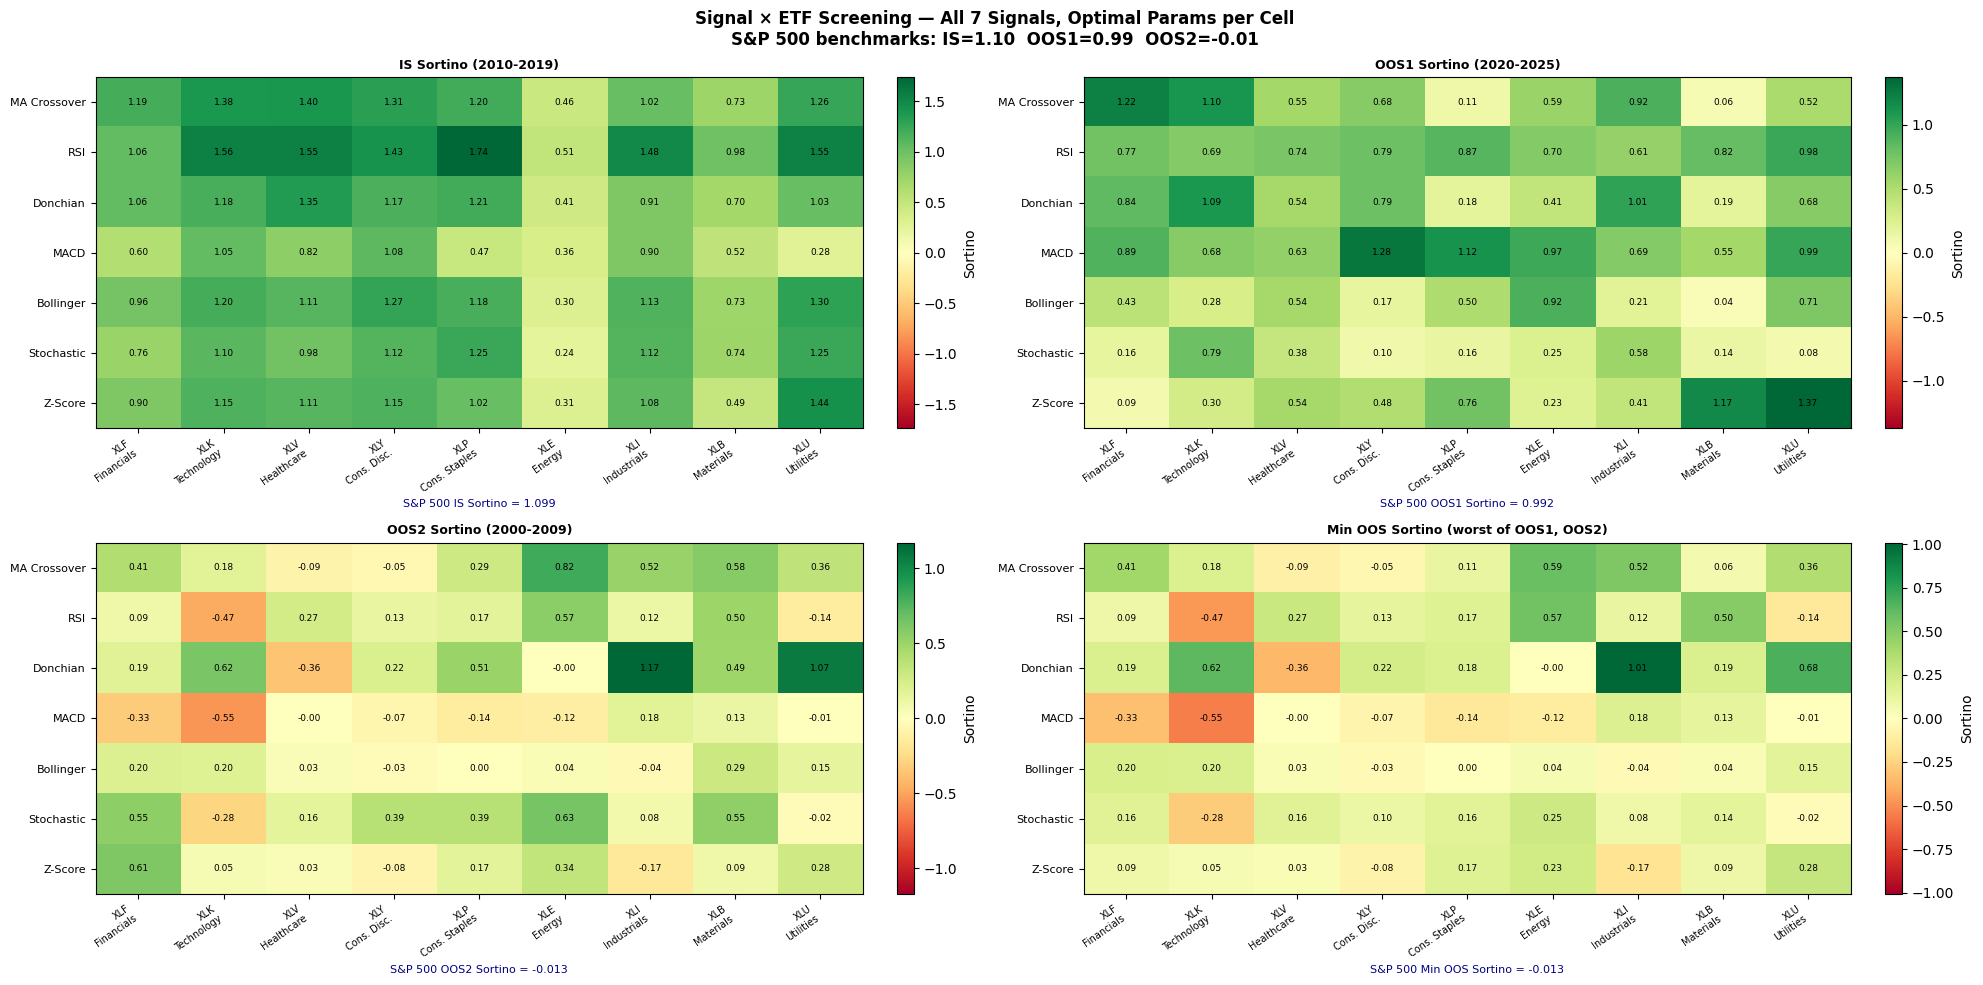

In [9]:
sig_names = list(SIGNAL_GRIDS.keys())
n_sig = len(sig_names)
n_etf = len(TICKERS)

mat_is   = np.full((n_sig, n_etf), np.nan)
mat_oos1 = np.full((n_sig, n_etf), np.nan)
mat_oos2 = np.full((n_sig, n_etf), np.nan)

for r, sn in enumerate(sig_names):
    for c, tk in enumerate(TICKERS):
        row = df_res[(df_res['Signal']==sn)&(df_res['ETF']==tk)]
        if len(row):
            mat_is[r,c]   = row['IS Sortino'].values[0]
            mat_oos1[r,c] = row['OOS1 Sortino'].values[0]
            mat_oos2[r,c] = row['OOS2 Sortino'].values[0]

mat_min = np.fmin(mat_oos1, mat_oos2)

def heatmap(ax, mat, col_lbls, row_lbls, title, spx_line=None):
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat))) if not np.all(np.isnan(mat)) else 1
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(len(col_lbls)))
    ax.set_xticklabels(col_lbls, fontsize=7, rotation=35, ha='right')
    ax.set_yticks(range(len(row_lbls)))
    ax.set_yticklabels(row_lbls, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    mid = 0
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat[r, c]
            if v == v:
                tc = 'black' if abs(v) < vabs*0.6 else ('white' if v < 0 else 'black')
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6.5, color=tc)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')
    if spx_line is not None:
        ax.axhline(-0.5, color='none')  # spacer

etf_lbls = [f'{tk}\n{SECTOR_ETFS[tk]}' for tk in TICKERS]

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle('Signal × ETF Screening — All 7 Signals, Optimal Params per Cell\n'
             f'S&P 500 benchmarks: IS={SPX_IS:.2f}  OOS1={SPX_OOS1:.2f}  OOS2={SPX_OOS2:.2f}',
             fontsize=12, fontweight='bold')

heatmap(axes[0,0], mat_is,   etf_lbls, sig_names, 'IS Sortino (2010-2019)')
heatmap(axes[0,1], mat_oos1, etf_lbls, sig_names, 'OOS1 Sortino (2020-2025)')
heatmap(axes[1,0], mat_oos2, etf_lbls, sig_names, 'OOS2 Sortino (2000-2009)')
heatmap(axes[1,1], mat_min,  etf_lbls, sig_names, 'Min OOS Sortino (worst of OOS1, OOS2)')

# Draw S&P 500 Sortino as reference lines on colorbars (via text)
for ax, spx_v, period in zip(axes.flat, [SPX_IS, SPX_OOS1, SPX_OOS2, min(SPX_OOS1,SPX_OOS2)],
                              ['IS','OOS1','OOS2','Min OOS']):
    ax.set_xlabel(f'S&P 500 {period} Sortino = {spx_v:.3f}', fontsize=8, color='navy')

plt.tight_layout(); plt.show()

In [10]:
# How many ETFs per signal beat S&P 500 in each period?
print(f'Cells that beat S&P 500 Sortino (IS={SPX_IS:.3f} | OOS1={SPX_OOS1:.3f} | OOS2={SPX_OOS2:.3f})')
print()
W = 72
print(f'  {"Signal":<14} {"Beat IS":>9} {"Beat OOS1":>11} {"Beat OOS2":>11} {"Beat BOTH OOS":>14}')
print('  ' + '-'*(W-2))
for sn in sig_names:
    sub = df_res[df_res['Signal']==sn]
    n = len(sub)
    bi   = int((sub['IS Sortino']   > SPX_IS  ).sum())
    bo1  = int((sub['OOS1 Sortino'] > SPX_OOS1).sum())
    bo2  = int((sub['OOS2 Sortino'] > SPX_OOS2).sum())
    both = int(((sub['OOS1 Sortino'] > SPX_OOS1) & (sub['OOS2 Sortino'] > SPX_OOS2)).sum())
    print(f'  {sn:<14} {bi:>4}/{n}    {bo1:>4}/{n}      {bo2:>4}/{n}        {both:>4}/{n}')
print('  ' + '-'*(W-2))
print(f'  (/{n} = out of {n} ETFs tested per signal)')

Cells that beat S&P 500 Sortino (IS=1.099 | OOS1=0.992 | OOS2=-0.013)

  Signal           Beat IS   Beat OOS1   Beat OOS2  Beat BOTH OOS
  ----------------------------------------------------------------------
  MA Crossover      6/9       2/9         7/9           2/9
  RSI               6/9       0/9         7/9           0/9
  Donchian          4/9       2/9         8/9           2/9
  MACD              0/9       2/9         4/9           0/9
  Bollinger         6/9       0/9         7/9           0/9
  Stochastic        5/9       0/9         7/9           0/9
  Z-Score           4/9       2/9         7/9           2/9
  ----------------------------------------------------------------------
  (/9 = out of 9 ETFs tested per signal)


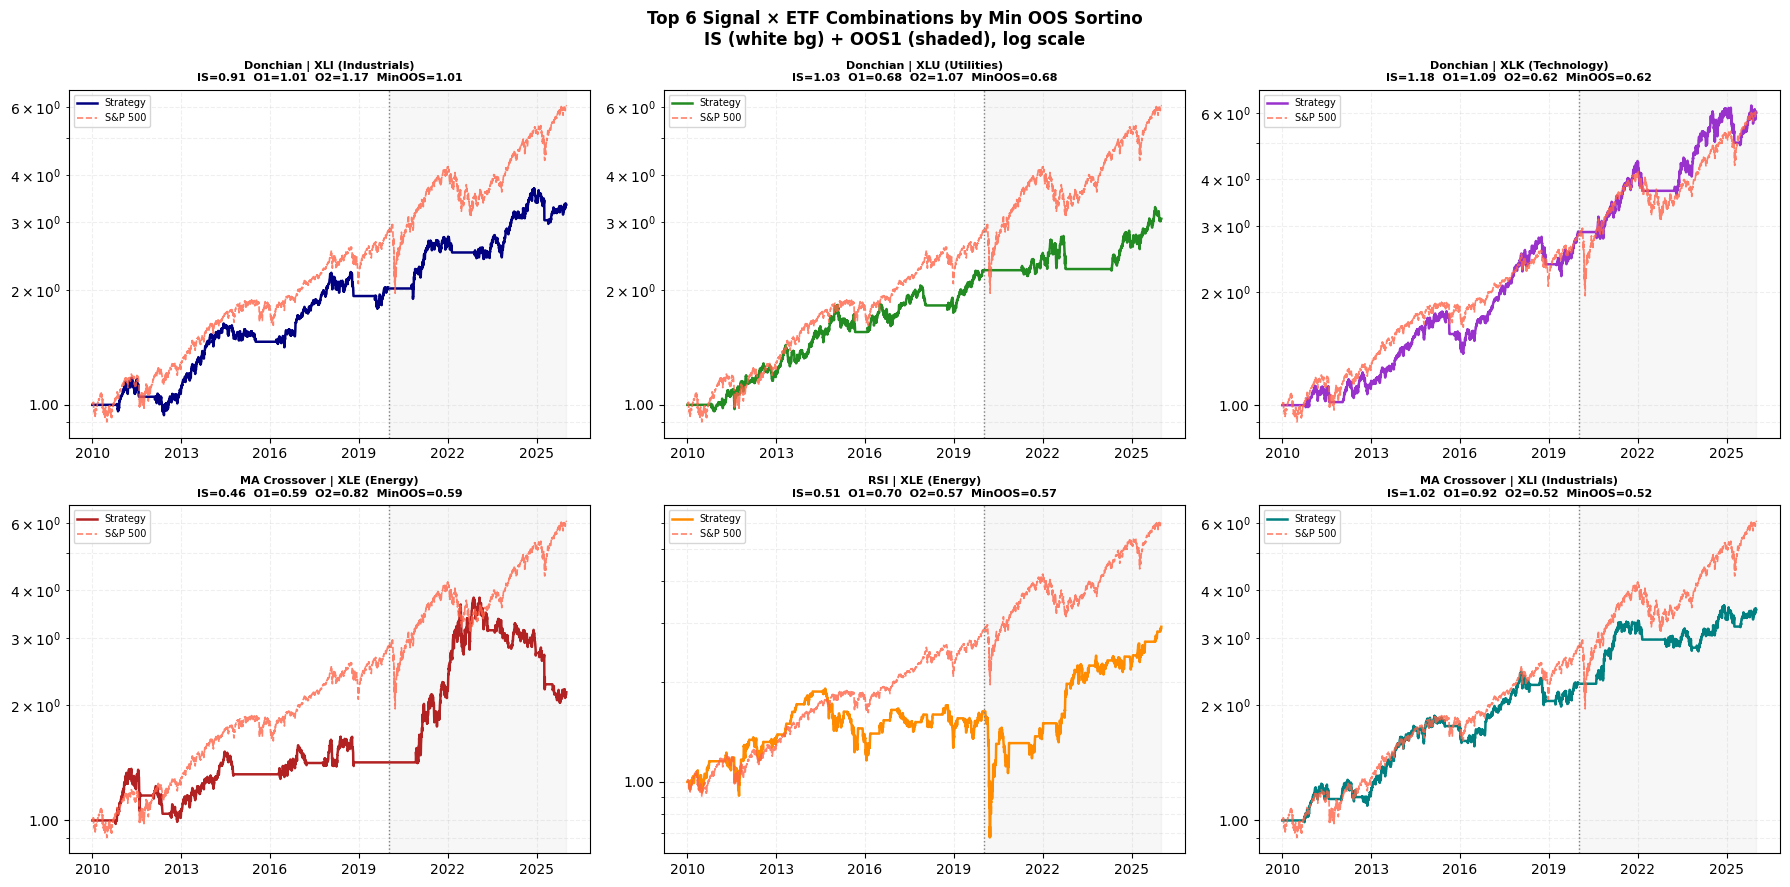

In [11]:
# Equity curves for the top 6 Min-OOS combinations vs S&P 500
top6 = df_res.dropna(subset=['Min OOS']).sort_values('Min OOS', ascending=False).head(6)

def _spx_norm(df_ref, idx):
    col = df_ref.columns[0]
    v = df_ref[col].reindex(idx, method='ffill').to_numpy(dtype=float)
    return v / v[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Top 6 Signal × ETF Combinations by Min OOS Sortino\n'
             'IS (white bg) + OOS1 (shaded), log scale',
             fontsize=12, fontweight='bold')

_colors = ['navy','forestgreen','darkorchid','firebrick','darkorange','teal']

for ax, (_, row), col in zip(axes.flat, top6.iterrows(), _colors):
    sn = row['Signal']; tk = row['ETF']
    sig_fn = SIGNAL_GRIDS[sn][0]
    bp     = opt[sn][tk]['params']
    if bp is None or tk not in df_is.columns:
        ax.set_title('No data'); continue

    pv_is,  _ = single_etf_pv(sig_fn, df_is[tk],   bp)
    pv_o1, _  = single_etf_pv(sig_fn, df_oos1[tk], bp)

    idx_is = df_is.index.to_numpy()
    idx_o1 = df_oos1.index.to_numpy()
    idx_all = np.concatenate([idx_is, idx_o1])
    pv_all  = np.concatenate([pv_is, pv_o1 / pv_o1[0] * pv_is[-1]])

    # S&P 500 over same window
    spx_is_v  = _spx_norm(df_spx, df_is.index)
    spx_o1_v  = _spx_norm(df_spx, df_oos1.index)
    spx_all   = np.concatenate([spx_is_v, spx_o1_v/spx_o1_v[0]*spx_is_v[-1]])

    ax.semilogy(idx_all, pv_all,  color=col,     lw=1.8, label='Strategy')
    ax.semilogy(idx_all, spx_all, color='tomato', lw=1.2, linestyle='--',
                label='S&P 500', alpha=0.8)
    ax.axvline(pd.Timestamp(OOS1_START), color='grey', lw=1.0, linestyle=':')
    ax.axvspan(pd.Timestamp(OOS1_START), idx_o1[-1], alpha=0.06, color='grey')
    ax.set_title(
        f'{sn} | {tk} ({SECTOR_ETFS[tk]})\n'
        f'IS={row["IS Sortino"]:.2f}  O1={row["OOS1 Sortino"]:.2f}  '
        f'O2={row["OOS2 Sortino"]:.2f}  MinOOS={row["Min OOS"]:.2f}',
        fontsize=8, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.2, linestyle='--')

plt.tight_layout(); plt.show()

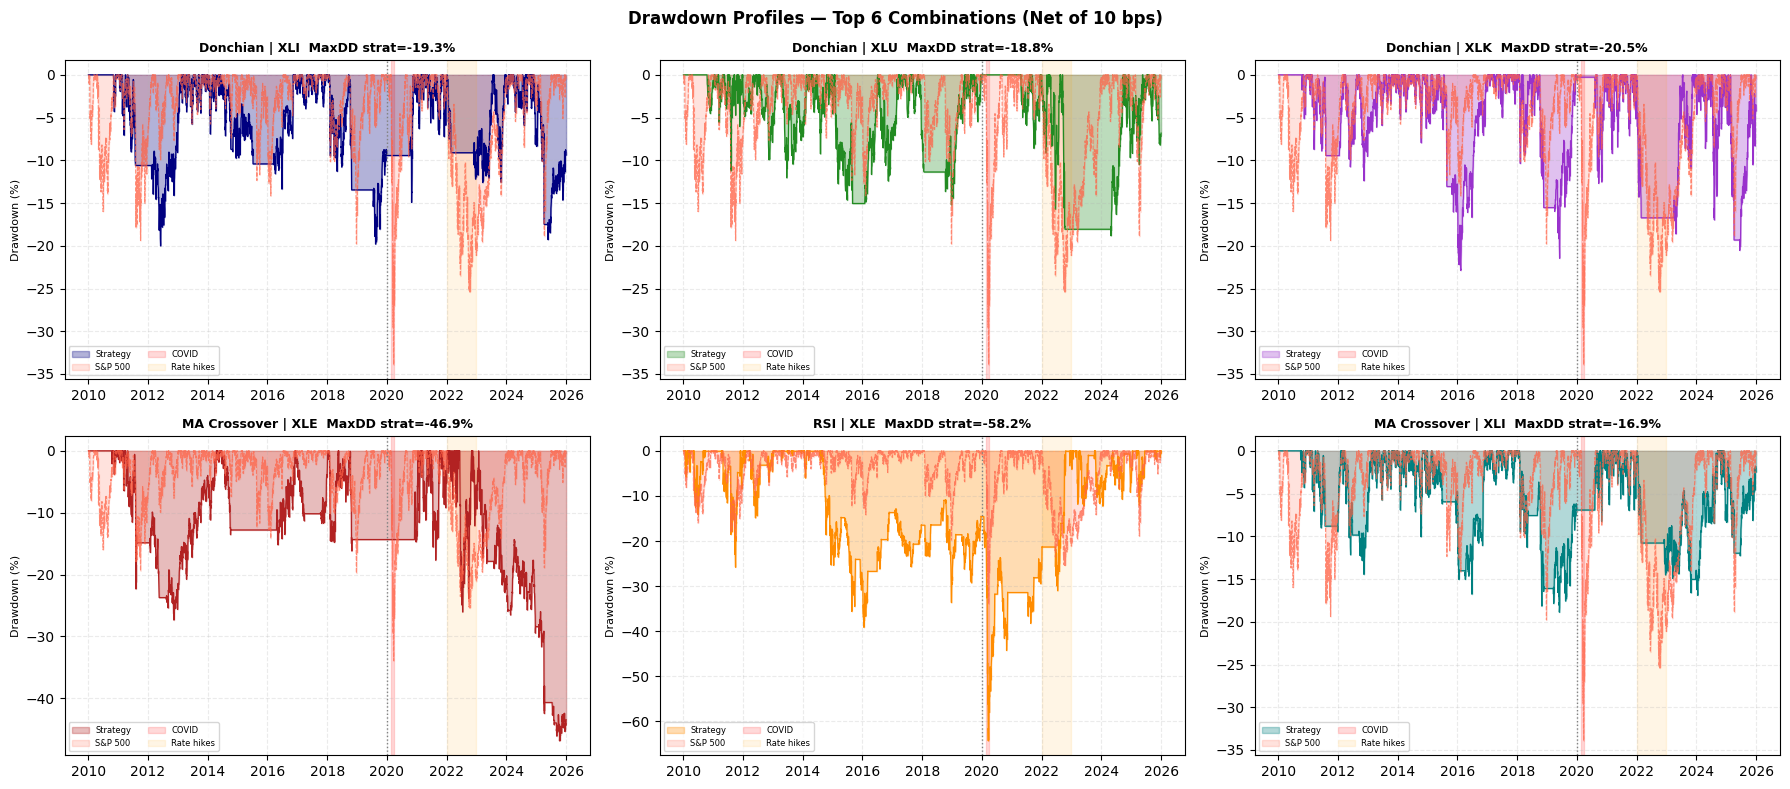

In [12]:
# Drawdown profiles for the same top 6
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Drawdown Profiles — Top 6 Combinations (Net of 10 bps)',
             fontsize=12, fontweight='bold')

_covid_s = pd.Timestamp('2020-02-19'); _covid_e = pd.Timestamp('2020-03-23')
_hike_s  = pd.Timestamp('2022-01-03'); _hike_e  = pd.Timestamp('2022-12-30')

for ax, (_, row), col in zip(axes.flat, top6.iterrows(), _colors):
    sn = row['Signal']; tk = row['ETF']
    sig_fn = SIGNAL_GRIDS[sn][0]
    bp     = opt[sn][tk]['params']
    if bp is None or tk not in df_is.columns:
        ax.set_title('No data'); continue

    pv_is, _ = single_etf_pv(sig_fn, df_is[tk],   bp)
    pv_o1, _ = single_etf_pv(sig_fn, df_oos1[tk], bp)
    idx_all  = np.concatenate([df_is.index.to_numpy(), df_oos1.index.to_numpy()])
    pv_all   = np.concatenate([pv_is, pv_o1/pv_o1[0]*pv_is[-1]])
    spx_all  = np.concatenate([_spx_norm(df_spx, df_is.index),
                                _spx_norm(df_spx, df_oos1.index)])
    spx_all  = np.concatenate([_spx_norm(df_spx, df_is.index),
                                _spx_norm(df_spx, df_oos1.index) /
                                _spx_norm(df_spx, df_oos1.index)[0] *
                                _spx_norm(df_spx, df_is.index)[-1]])

    dd_s = module.compute_drawdown_series(pv_all)  * 100
    dd_b = module.compute_drawdown_series(spx_all) * 100

    ax.fill_between(idx_all, dd_s, 0, color=col,     alpha=0.30, label='Strategy')
    ax.fill_between(idx_all, dd_b, 0, color='tomato', alpha=0.18, label='S&P 500')
    ax.plot(idx_all, dd_s, color=col,     lw=0.9)
    ax.plot(idx_all, dd_b, color='tomato', lw=0.8, linestyle='--', alpha=0.7)
    ax.axvspan(_covid_s, _covid_e, alpha=0.15, color='red',    label='COVID')
    ax.axvspan(_hike_s,  _hike_e,  alpha=0.10, color='orange', label='Rate hikes')
    ax.axvline(pd.Timestamp(OOS1_START), color='grey', lw=1.0, linestyle=':')
    ax.set_title(f'{sn} | {tk}  MaxDD strat={row["OOS1 MaxDD"]:.1%}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(fontsize=6, loc='lower left', ncol=2)
    ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout(); plt.show()

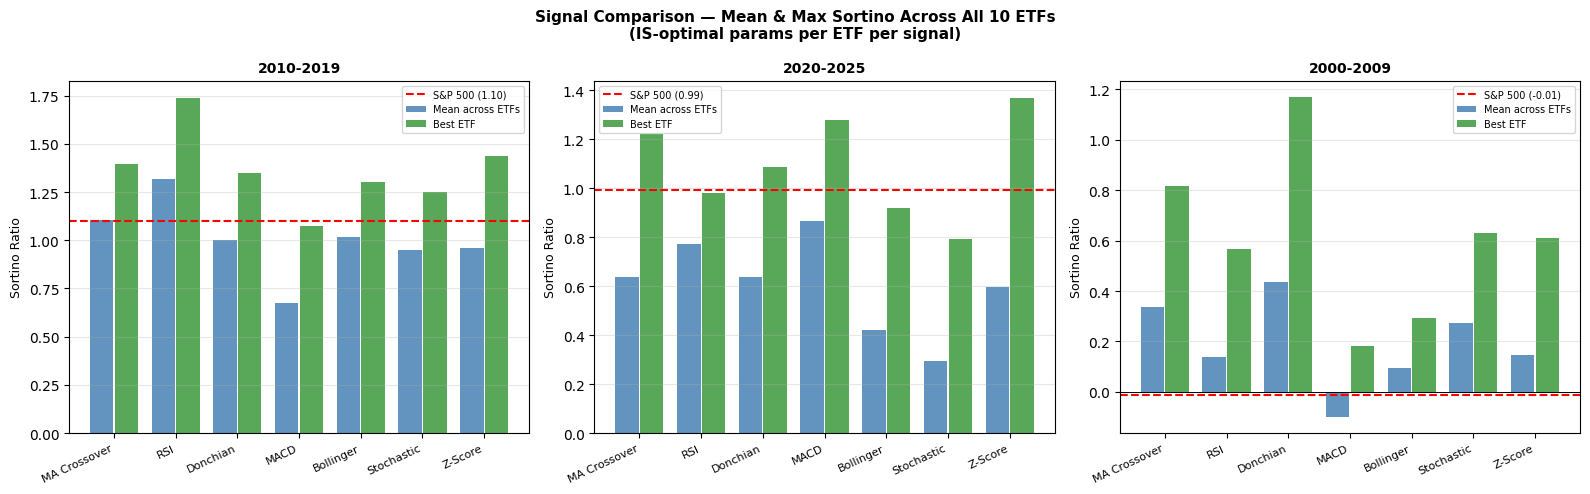

In [13]:
# Per-signal summary: mean and max Sortino across all ETFs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Signal Comparison — Mean & Max Sortino Across All 10 ETFs\n'
             '(IS-optimal params per ETF per signal)',
             fontsize=11, fontweight='bold')

periods = [('IS Sortino', SPX_IS, '2010-2019'),
           ('OOS1 Sortino', SPX_OOS1, '2020-2025'),
           ('OOS2 Sortino', SPX_OOS2, '2000-2009')]

for ax, (col, spx_v, period) in zip(axes, periods):
    means = [df_res[df_res['Signal']==sn][col].mean() for sn in sig_names]
    maxes = [df_res[df_res['Signal']==sn][col].max()  for sn in sig_names]
    x = np.arange(len(sig_names))
    ax.bar(x - 0.2, means, 0.38, label='Mean across ETFs', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, maxes, 0.38, label='Best ETF',         color='forestgreen', alpha=0.75)
    ax.axhline(spx_v, color='red', lw=1.5, linestyle='--',
               label=f'S&P 500 ({spx_v:.2f})')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(sig_names, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{period}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Sortino Ratio', fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## Takeaways

- The **Mean across all ETFs** (blue bars) shows signal edge before sector selection.
- The **Best ETF** (green bars) shows peak performance after screening — this is what the main research notebook captures after IS optimisation + ETF assignment.
- The **red dashed line** is the S&P 500. Bars above it beat the benchmark.

**Key observations to discuss:**
- OOS2 (2000–2009) is where long-only signals earn their keep: the S&P 500 had negative total returns that decade. Any strategy with positive OOS2 Sortino is genuinely beating the benchmark where it matters.
- Signals that show *higher* OOS than IS Sortino on the best ETF are a positive sign — it suggests the IS result was conservative, not overfit.
- The Min OOS heatmap is the most honest robustness measure: a cell must hold up in *both* OOS periods to be considered reliable.